# The Airbnb Effect: Milan Data Processing & EDA

This notebook will load the datasets downloaded from *Inside Airbnb* for the city of Milan. We will merge them, clean missing values, and analyze the distribution of Airbnbs compared to neighborhoods.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for seaborn
sns.set_theme(style="whitegrid")
print('Libraries imported successfully.')

Libraries imported successfully.


## 1. Load the Data
Let's load the files downloaded inside the `data/` folder.

In [2]:
# Load listings data
listings_df = pd.read_csv('data/listings.csv')

# Show basic info
print(f"Listings Dataset Shape: {listings_df.shape}")
listings_df.head(3)

Listings Dataset Shape: (22948, 18)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,23986,""" Characteristic Milanese flat""",95941,Jeremy,NaN,NAVIGLI,45.44806,9.17373,Entire home/apt,180.0,31,26,2024-04-20,0.16,1,362,0,NaN
1,40470,Giacinto Cosy & clean flat near MM1,174203,Giacinto,NaN,VIALE MONZA,45.52023,9.22747,Entire home/apt,NaN,3,44,2025-07-31,0.24,2,357,1,IT015146C2YDCLSU8G
2,46536,Nico & Cinzia's Pink Suite!,138683,Nico&Cinzia,NaN,VIALE MONZA,45.52276,9.22478,Entire home/apt,86.0,3,39,2025-04-20,0.23,1,111,2,IT015209C2BBKGCMT7


GeoJSON Neighborhoods Shape: (88, 3)


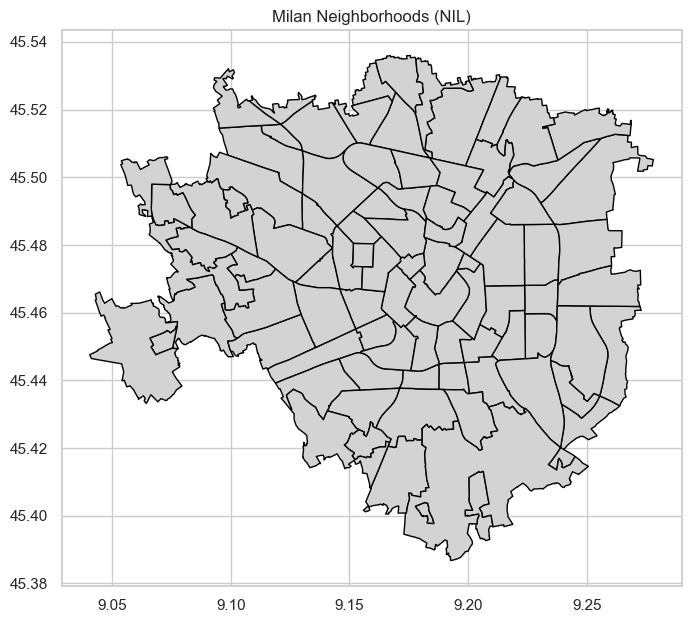

In [3]:
# Load GeoJSON of neighborhoods for spatial visualization later
neighborhoods_gdf = gpd.read_file('data/neighbourhoods.geojson')
print(f"GeoJSON Neighborhoods Shape: {neighborhoods_gdf.shape}")
neighborhoods_gdf.plot(figsize=(8,8), edgecolor='black', color='lightgrey')
plt.title('Milan Neighborhoods (NIL)')
plt.show()

## 2. Data Cleaning
We need to clean the `price` column (removing the `$` sign and converting to float), handle NaN values in important columns, and drop listings that do not make sense (e.g., price = 0, or extreme outliers).

In [ ]:
# Price comes as a string with '$' and ','. Let's clean it.
listings_df['price'] = listings_df['price'].astype(str).replace({'\\$': '', ',': ''}, regex=True).astype(float)

# Drop rows where price is missing or 0
listings_df = listings_df.dropna(subset=['price'])
listings_df = listings_df[listings_df['price'] > 0]

# Handle other missing values: reviews_per_month to 0
listings_df['reviews_per_month'] = listings_df['reviews_per_month'].fillna(0)

# Drop irrelevant columns or columns with mostly nulls
columns_to_drop = ['neighbourhood_group', 'license']
listings_df = listings_df.drop(columns=columns_to_drop, errors='ignore')

print(f"Cleaned dataset shape: {listings_df.shape}")
listings_df.describe()

## 3. Exploratory Data Analysis
Let's check the price distribution and the top neighborhoods with the most Airbnbs. We'll also spatial join with the GeoJSON to view the map.

In [ ]:
# Price Distribution (Filtered to < 1000 for visibility)
plt.figure(figsize=(10, 6))
sns.histplot(listings_df[listings_df['price'] < 1000]['price'], bins=50, kde=True, color='teal')
plt.title('Distribution of Airbnb Prices in Milan (Under 1000€)')
plt.xlabel('Price (€)')
plt.ylabel('Count')
plt.show()

In [ ]:
# Top 10 Neighbourhoods by number of listings
top_neighbourhoods = listings_df['neighbourhood'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(y=top_neighbourhoods.index, x=top_neighbourhoods.values, palette='viridis')
plt.title('Top 10 Milan Neighbourhoods by Number of Airbnb Listings')
plt.xlabel('Number of Listings')
plt.ylabel('Neighbourhood')
plt.show()

In [ ]:
# Calculate average price per neighbourhood and merge with GeoPandas
avg_price_df = listings_df.groupby('neighbourhood')['price'].mean().reset_index()
avg_price_df.columns = ['neighbourhood', 'avg_price']

# Assume neighborhoods_gdf has a 'neighborhood' or 'NIL_NM' column depending on the Milan open data structure.
# Inside Airbnb geojson usually uses 'neighbourhood'
map_df = neighborhoods_gdf.merge(avg_price_df, on='neighbourhood', how='left')

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
map_df.plot(column='avg_price', cmap='OrRd', ax=ax, legend=True, 
            legend_kwds={'label': "Average Price (€)", 'orientation': "vertical"},
            missing_kwds={"color": "lightgrey", "label": "No Data"})
plt.title('Average Airbnb Price per Neighbourhood in Milan')
ax.set_axis_off()
plt.show()

### Target Question check: Professional vs Casual Hosts
Let's see the split of hosts with a single listing vs hosts with multiple listings.

In [ ]:
# Count hosts
hosts_listings_count = listings_df[['host_id', 'calculated_host_listings_count']].drop_duplicates()

def categorize_host(listings_count):
    if listings_count == 1:
        return 'Single-listing (Casual)'
    elif listings_count <= 3:
        return '2-3 listings'
    else:
        return '4+ listings (Professional)'

hosts_listings_count['host_type'] = hosts_listings_count['calculated_host_listings_count'].apply(categorize_host)

host_counts = hosts_listings_count['host_type'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(host_counts, labels=host_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'], startangle=90)
plt.title('Proportion of Host Types in Milan')
plt.show()